
##### Importing Pandas library fro data Extraction

In [2]:
import pandas as pd

##### ________________________________________________________________
##### Import the data (HR-Employee-Attrition.csv) from local folder
##### __________________________________________________________________

In [3]:
# Load the HR Employee Attrition dataset
hr = pd.read_csv(r"HR-Employee-Attrition.csv")

# Initial exploration of the dataset
print("hr shape:", hr.shape)
print("Attrition dtype:", hr['Attrition'].dtype)

# Display unique values in the 'Attrition' column
print("Sample unique Attrition values (repr):", [repr(x) for x in pd.Series(hr['Attrition'].unique()).astype(str).tolist()[:50]])

# Display value counts for the 'Attrition' column including NaN values
print("Value counts including NaN:\n", hr['Attrition'].value_counts(dropna=False).head(20))
hr.head()

hr shape: (1470, 35)
Attrition dtype: object
Sample unique Attrition values (repr): ["'Yes'", "'No'"]
Value counts including NaN:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#### ________________________________________________________________
#### Importing libraries for SQL connection & building communcation
#### __________________________________________________________________

In [4]:
# import necessary libraries for MySQL connection

import mysql.connector
from sqlalchemy import create_engine

# Create a connection to the MySQL database
engine = create_engine('mysql+mysqlconnector://root:@localhost/hr_analytics') 

# Load data into MySQL
hr.to_sql('employees', con=engine, if_exists='replace', index=False)

print("Data loaded successfully into MySQL")

Data loaded successfully into MySQL


#### ________________________________________________________________________
#### Importing Libraries for Exploratory data Analysis and Pridiction Process
#### ------------------------------------------------------------------------

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Data Preparation

def prepare_data(hr):

    # Create a copy of the original dataframe
    hr_copy = hr.copy()

    # Keep the original for debugging
    hr_copy['Attrition_original'] = hr_copy['Attrition']

    # Normalize strings and handle common variants
    attr = hr_copy['Attrition'].astype(str).str.strip().str.lower()
    # Remove surrounding quotes or any non-alphanumeric characters
    attr = attr.str.replace(r"^[^a-z0-9]+|[^a-z0-9]+$", "", regex=True)

    mapping = {'yes': 1, 'y': 1, 'true': 1, 't': 1, '1': 1,
               'no': 0, 'n': 0, 'false': 0, 'f': 0, '0': 0}
    hr_copy['Attrition'] = attr.replace(mapping)

    # Try converting remaining values to numeric
    hr_copy['Attrition'] = pd.to_numeric(hr_copy['Attrition'], errors='coerce')

    # Report and drop any rows we couldn't map 
    missing = hr_copy['Attrition'].isnull().sum()
    if missing > 0:
        warnings.warn(f"{missing} rows have unknown 'Attrition' values after mapping; these rows will be dropped for EDA/modeling.")
        hr_copy = hr_copy.dropna(subset=['Attrition']).reset_index(drop=True)

    # Making sure Attrition is integer 0/1
    hr_copy['Attrition'] = hr_copy['Attrition'].astype(int)

    # Encoding Categorical Variables excluding Attrition_original
    categorical_cols = hr_copy.select_dtypes(include=['object', 'category']).columns.drop(['Attrition_original'], errors='ignore')

    label_encoder = {}
    for col in categorical_cols:
        le = LabelEncoder()
        hr_copy[col] = le.fit_transform(hr_copy[col].astype(str))
        label_encoder[col] = le

    return hr_copy    

# Prepare data

hr_copy = prepare_data(hr)

##### -------------------------------------------
##### Exploratory Data Analysis
##### -------------------------------------------

 === EXLORATORY DATA ANALYSIS ===

1. Overal Attrition Rate :
 16.12%

2. top 10 features correlated with attrition:
Attrition             1.000000
OverTime              0.246118
MaritalStatus         0.162070
DistanceFromHome      0.077924
JobRole               0.067151
Department            0.063991
NumCompaniesWorked    0.043494
Gender                0.029453
EducationField        0.026846
MonthlyRate           0.015170
Name: Attrition, dtype: float64


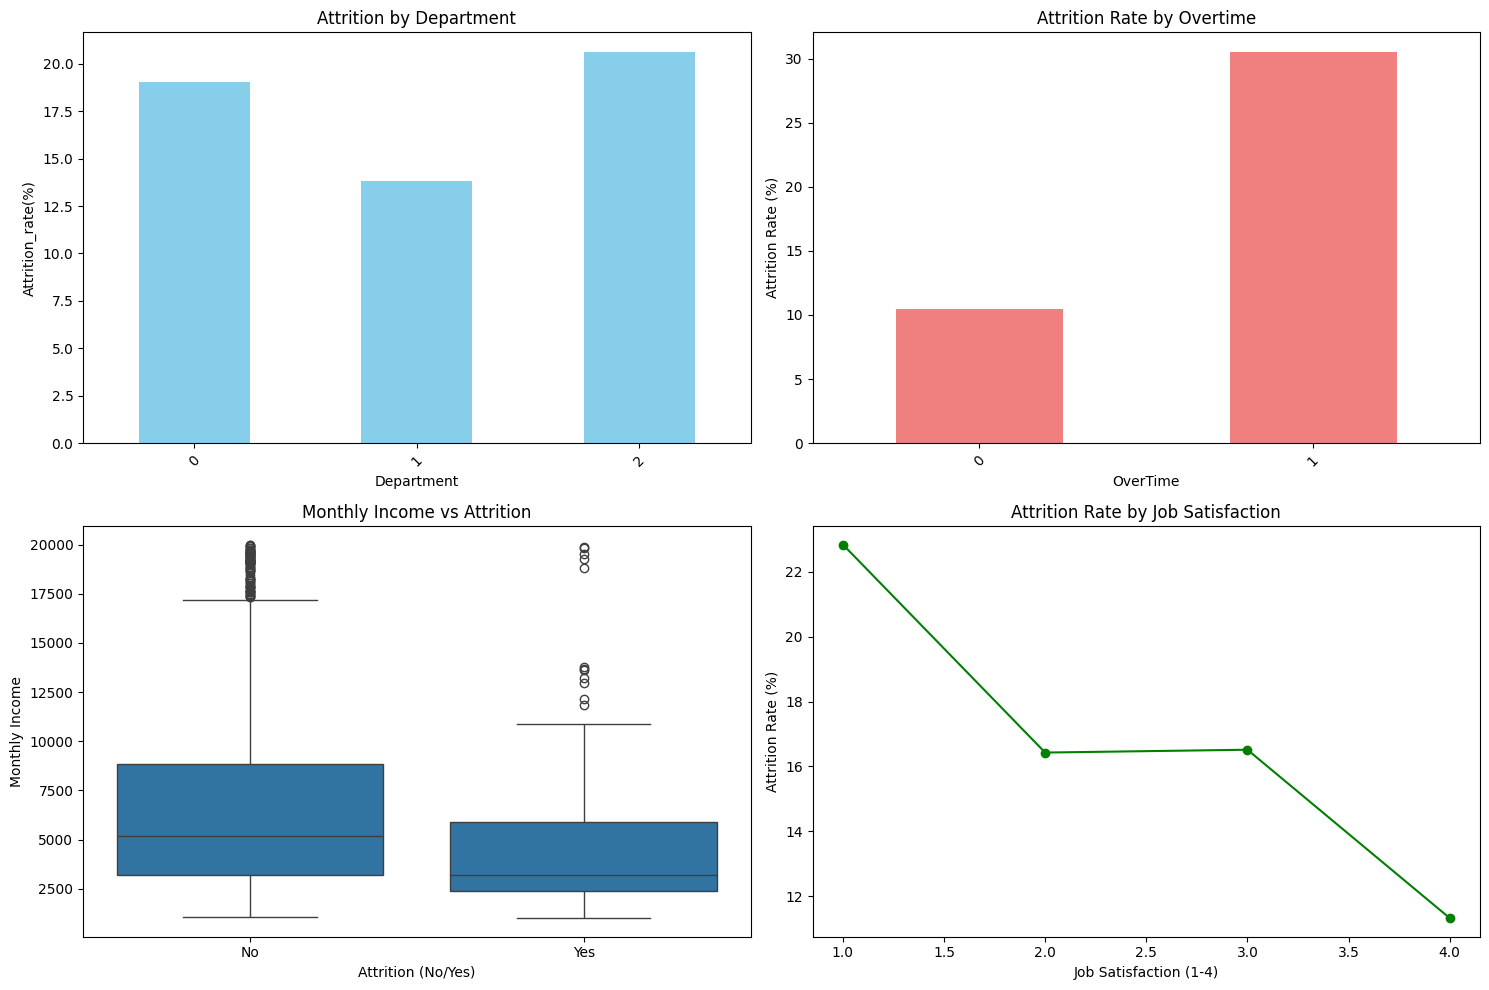

In [7]:
# creating Function for the EDA processing
def perform_eda(hr_copy):
    print(' === EXLORATORY DATA ANALYSIS ===')

    #1. Attrition Distribution
    if hr_copy.empty or 'Attrition' not in hr_copy.columns or hr_copy['Attrition'].isnull().all():
        print('\n1. No valid "Attrition" data available to compute attrition rate.')
        attrition_rate = float('nan')
    else:
        attrition_rate = hr_copy['Attrition'].mean() * 100
        print(f"\n1. Overal Attrition Rate :\n {attrition_rate:.2f}%")

    #2. Correlation with attrition
    numeric_cols = hr_copy.select_dtypes(include=[np.number]).columns.tolist()
    if 'Attrition' in numeric_cols:
        correlation = hr_copy[numeric_cols].corr()['Attrition'].sort_values(ascending=False)
        print(f'\n2. top 10 features correlated with attrition:\n{correlation.head(10)}')
    else:
        correlation = pd.Series(dtype=float)
        print('\n2. Cannot compute correlation because "Attrition" is not numeric or is missing.')

    #3. visualization
    plt.figure(figsize=(15, 10)) 

    #subplot 1: Attrition by Department
    plt.subplot(2, 2, 1)
    if 'Department' in hr_copy.columns and 'Attrition' in hr_copy.columns:
        dept_attrition = hr_copy.groupby('Department')['Attrition'].mean() * 100
        if dept_attrition.sum() == 0 and (dept_attrition == 0).all():
            plt.text(0.5, 0.5, 'No data available', ha='center')
        else:
            dept_attrition.plot(kind = 'bar', color='skyblue')
    else:
        plt.text(0.5, 0.5, 'Department or Attrition missing', ha='center')
    plt.title('Attrition by Department')
    plt.ylabel('Attrition_rate(%)')    
    plt.xticks(rotation = 45)

    # subplot 2: Attrition by Over time
    plt.subplot(2, 2, 2)
    if 'OverTime' in hr_copy.columns and 'Attrition' in hr_copy.columns:
        overtime_attrition = hr_copy.groupby('OverTime')['Attrition'].mean() * 100
        if overtime_attrition.sum() == 0 and (overtime_attrition == 0).all():
            plt.text(0.5, 0.5, 'No data available', ha='center')
        else:
            overtime_attrition.plot(kind='bar', color='lightcoral')
            plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'OverTime or Attrition missing', ha='center')
    plt.title('Attrition Rate by Overtime')
    plt.ylabel('Attrition Rate (%)')

    # subplot 3: Income vs Attrition
    plt.subplot(2, 2, 3)
    hr_box = hr_copy[['Attrition', 'MonthlyIncome']].copy() if set(['Attrition','MonthlyIncome']).issubset(hr_copy.columns) else pd.DataFrame()
    if hr_box.empty:
        plt.text(0.5, 0.5, 'No data available for MonthlyIncome by Attrition', ha='center')
    else:
        hr_box = hr_box.dropna(subset=['Attrition', 'MonthlyIncome'])
        if hr_box.empty:
            plt.text(0.5, 0.5, 'No data available for MonthlyIncome by Attrition', ha='center')
        else:
            hr_box['Attrition'] = hr_box['Attrition'].astype(int)
            hr_box['Attrition_label'] = hr_box['Attrition'].map({0: 'No', 1: 'Yes'})
            group_counts = hr_box['Attrition_label'].value_counts()
            order = group_counts[group_counts > 0].index.tolist()
            sns.boxplot(x='Attrition_label', y='MonthlyIncome', data=hr_box, order=order)
    plt.title('Monthly Income vs Attrition')
    plt.xlabel('Attrition (No/Yes)')
    plt.ylabel('Monthly Income')

    # Subplot 4: Job Satisfaction
    plt.subplot(2, 2, 4)
    if 'JobSatisfaction' in hr_copy.columns and 'Attrition' in hr_copy.columns:
        satisfaction_attrition = hr_copy.groupby('JobSatisfaction')['Attrition'].mean() * 100
        if satisfaction_attrition.empty:
            plt.text(0.5, 0.5, 'No data for JobSatisfaction', ha='center')
        else:
            satisfaction_attrition.plot(kind='line', marker='o', color='green')
    else:
        plt.text(0.5, 0.5, 'JobSatisfaction or Attrition missing', ha='center')
    plt.title('Attrition Rate by Job Satisfaction')
    plt.xlabel('Job Satisfaction (1-4)')
    plt.ylabel('Attrition Rate (%)')

    plt.tight_layout()
    plt.show()

    return correlation

# run EDA

correlation = perform_eda(hr_copy)

##### ------------------------------------
##### Predictive Modeling
##### -----------------------------------

In [14]:
# Creating Function for prediction modeling
def build_model(hr_copy):
    print("\n === PREDICTION MODELING ===")

    # Prepare features and target
    # Drop known non-feature columns; errors='ignore' prevents KeyError if a column is missing
    X = hr_copy.drop(['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours'], axis=1, errors='ignore')
    y = hr_copy['Attrition']

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # Scale full feature set for consistent final predictions
    X_scaled_full = scaler.transform(X)

    # 1. Logistic Regression
    print("\n1. Logistic Regression Results:")
    lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    lr_model.fit(X_train_scaled, y_train)
    y_pred_lr = lr_model.predict(X_test_scaled)
    y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

    print(classification_report(y_test, y_pred_lr))
    print(f"ROC-AUC Score (Logistic Regression): {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

    # 2. Random Forest
    print("\n2. Random Forest Results:")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
    # Fit on scaled features for consistency
    rf_model.fit(X_train_scaled, y_train)
    y_pred_rf = rf_model.predict(X_test_scaled)
    y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    print(classification_report(y_test, y_pred_rf))
    print(f"ROC-AUC Score (Random Forest): {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
    
    # Feature Importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n3. Top 10 Feature Importance:")
    print(feature_importance.head(10))

    # Add prediction probabilities and risk levels to original data (use scaled full features)
    hr_copy = hr_copy.copy()  # avoid accidental side-effects
    hr_copy['Attrition_Probability'] = rf_model.predict_proba(X_scaled_full)[:, 1]
    hr_copy['Risk_Level'] = pd.cut(
        hr_copy['Attrition_Probability'],
        bins=[0, 0.3, 0.7, 1],
        labels=['Low', 'Medium', 'High'],
        include_lowest=True
    )
    
    return rf_model, feature_importance, hr_copy

# Build model
model, feature_importance, data_with_predictions = build_model(hr_copy)

# Financial Impact Analysis
def financial_impact_analysis(hr_df):
    print("\n=== FINANCIAL IMPACT ANALYSIS ===")
    
    # Calculate cost of attrition (6 months salary)
    hr_df = hr_df.copy()
    hr_df['Attrition_Cost'] = hr_df['MonthlyIncome'] * 6
    
    # Total actual attrition cost (based on actual Attrition flag)
    total_potential_cost = hr_df[hr_df['Attrition'] == 1]['Attrition_Cost'].sum()
    
    # Cost by department for actual attritions
    cost_by_dept = hr_df[hr_df['Attrition'] == 1].groupby('Department')['Attrition_Cost'].sum()
    
    # High-risk employees (Risk_Level == 'High')
    high_risk_employees = hr_df[hr_df['Risk_Level'] == 'High']
    potential_savings = high_risk_employees['MonthlyIncome'].sum() * 6 * 0.5  # Assuming 50% can be retained
    
    print(f"Total Actual Attrition Cost: ${total_potential_cost:,.0f}")
    print(f"\nCost by Department:")
    for dept, cost in cost_by_dept.items():
        print(f"  {dept}: ${cost:,.0f}")
    
    print(f"\nHigh-Risk Employees (>70% probability): {len(high_risk_employees)}")
    print(f"Potential Savings if 50% Retained: ${potential_savings:,.0f}")
    
    return {
        'total_cost': total_potential_cost,
        'high_risk_count': len(high_risk_employees),
        'potential_savings': potential_savings
    }

# Run financial analysis
financial_results = financial_impact_analysis(data_with_predictions)

# Save predictions for Power BI
data_with_predictions.to_csv('employee_data_with_predictions.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print("\n=== ANALYSIS COMPLETE ===")
print("Files saved for Power BI dashboard:")
print("1. employee_data_with_predictions.csv")
print("2. feature_importance.csv")
print("3. eda_visualizations.png")
print("\n=== ANALYSIS COMPLETE ===")
print("Files saved for Power BI dashboard:")
print("1. employee_data_with_predictions.csv")
print("2. feature_importance.csv")
print("3. eda_visualizations.png")


 === PREDICTION MODELING ===


ValueError: could not convert string to float: 'No'